# Bloque 1

In [11]:
import os
os.chdir('C:/Users/dbaca/OneDrive/Escriptori')
os.getcwd()

'C:\\Users\\dbaca\\OneDrive\\Escriptori'

In [80]:
#librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
color_pal = sns.color_palette()
from sklearn.model_selection import train_test_split
import statsmodels.api as sm


In [13]:
from Wilcox1 import multiplicar_2, al_cuadrado

In [22]:
np.random.seed(42)


# Bloque 2

In [29]:
raw_datos=pd.read_csv('C:/Users/dbaca/OneDrive/Escriptori/datos.train.csv')
raw_datos.head()

,Unnamed: 0,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,...,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,var127,TARGET
0,2,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0.012858,0
1,7,14,2,27,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94956.66,0.391089,0
2,8,18,2,26,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,251638.95,0.300590,0
3,10,23,2,25,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,356463.06,0.022430,0
4,12,26,2,26,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75368.52,0.004120,0


In [ ]:
#Si fuera con xlsx sería pd.read_excel('C:/Users/dbaca/OneDrive/Escriptori/datos.train.xlsx')

In [25]:
#analisis descriptivo
raw_datos.describe(include='all')

,Unnamed: 0,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,...,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,var127,TARGET
count,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,...,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,38010.000000,3.801000e+04,38010.000000,38010.000000
mean,38060.976164,76065.029729,-1654.706393,33.194002,92.963016,73.290068,121.421928,3.690524,6.302968,0.353967,...,1.835118,15.594873,10.832218,34.816803,2.417265,85.788744,63.089389,1.178106e+05,0.116473,0.039779
std,21948.081287,43787.688834,40678.751603,12.976992,1824.112772,336.433187,544.843289,94.972722,137.523855,20.308958,...,136.901968,989.664698,663.258073,2581.527569,176.649320,5136.479134,3622.658504,1.920677e+05,0.101552,0.195442
min,2.000000,3.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.856210e+03,0.000009,0.000000
25%,19056.250000,38214.500000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.779936e+04,0.038701,0.000000
50%,38173.500000,76346.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064489e+05,0.088646,0.000000
75%,57021.750000,113758.750000,2.000000,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.189949e+05,0.166945,0.000000
max,76019.000000,151836.000000,229.000000,102.000000,210000.000000,8520.060000,16086.060000,7904.220000,9133.980000,1800.000000,...,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,0.763612,1.000000


In [27]:
#eliminar NAs y valores repetidos
raw_datos.dropna().drop_duplicates()

,Unnamed: 0,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,...,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,var127,TARGET
0,2,3,2,34,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0.012858,0
1,7,14,2,27,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,94956.66,0.391089,0
2,8,18,2,26,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,251638.95,0.300590,0
3,10,23,2,25,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,356463.06,0.022430,0
4,12,26,2,26,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,75368.52,0.004120,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38005,76015,151825,2,39,0.0,375.99,405.33,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,90214.17,0.005650,0
38006,76016,151829,2,48,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60926.49,0.180802,0
38007,76017,151830,2,39,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118634.52,0.030163,0
38008,76018,151835,2,23,0.0,0.00,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,74028.15,0.015513,0


In [40]:
src_train = raw_datos.copy()
src_train['ID'] = src_train['ID'].astype(str)
print(src_train.ID.dtype)

object


In [ ]:
#Elimino la primera columna
src_train=src_train.drop(df.columns[0], axis=1)

# Bloque 3

<Axes: >

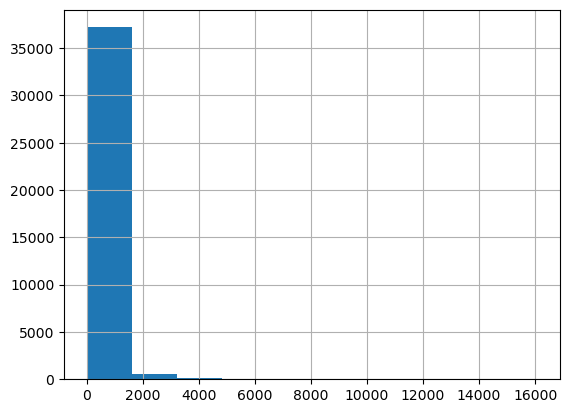

In [43]:
src_train.imp_op_var39_comer_ult3.hist(color=color_pal[0])

<Axes: xlabel='imp_op_var39_comer_ult3', ylabel='Count'>

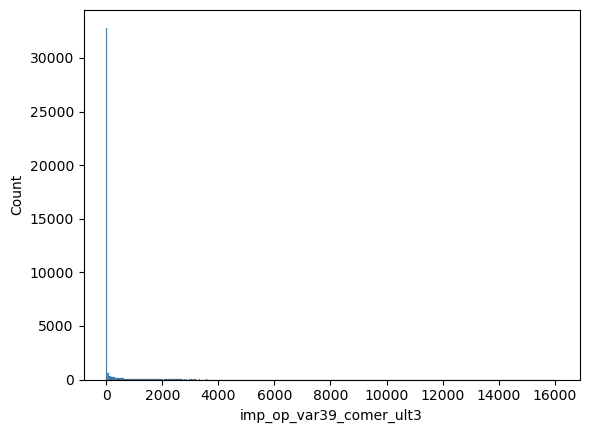

In [41]:
sns.histplot(data=src_train,
             x='imp_op_var39_comer_ult3',
             color=color_pal[0])

In [47]:
src_train.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38010 entries, 0 to 38009
Data columns (total 373 columns):
 #    Column                         Dtype  
---   ------                         -----  
 0    Unnamed: 0                     int64  
 1    ID                             object 
 2    var3                           int64  
 3    var15                          int64  
 4    imp_ent_var16_ult1             float64
 5    imp_op_var39_comer_ult1        float64
 6    imp_op_var39_comer_ult3        float64
 7    imp_op_var40_comer_ult1        float64
 8    imp_op_var40_comer_ult3        float64
 9    imp_op_var40_efect_ult1        float64
 10   imp_op_var40_efect_ult3        float64
 11   imp_op_var40_ult1              float64
 12   imp_op_var41_comer_ult1        float64
 13   imp_op_var41_comer_ult3        float64
 14   imp_op_var41_efect_ult1        float64
 15   imp_op_var41_efect_ult3        float64
 16   imp_op_var41_ult1              float64
 17   imp_op_var39_efect_ult1      

In [54]:
src_train['saldo_medio_var13_medio_ult1'].value_counts()

saldo_medio_var13_medio_ult1
0        38008
30000        1
9000         1
Name: count, dtype: int64

In [55]:
src_train['TARGET'].value_counts(normalize=True)

TARGET
0    0.960221
1    0.039779
Name: proportion, dtype: float64

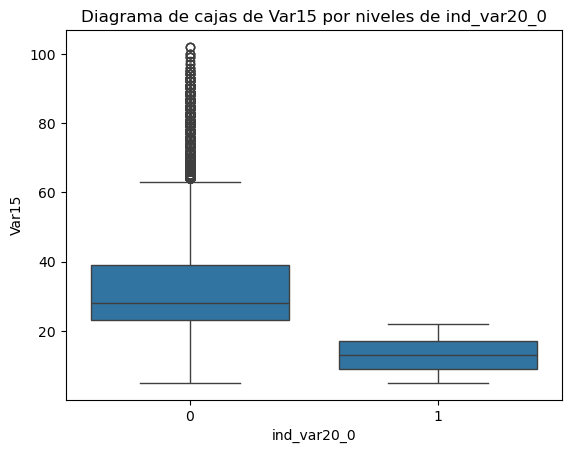

In [58]:
#Gráfico
sns.boxplot(x='ind_var20_0', y='var15', data=src_train)

plt.title('Diagrama de cajas de Var15 por niveles de ind_var20_0')
plt.xlabel('ind_var20_0')
plt.ylabel('Var15')
plt.show()


In [ ]:
#para sacar los outliers se tendría que crear una función

In [63]:
# variable con log
src_train['var127_log']=np.log(src_train['var127'])


In [67]:
#variable normalizada
src_train['var127_normalized'], lmbda= stats.boxcox(src_train['var127'])

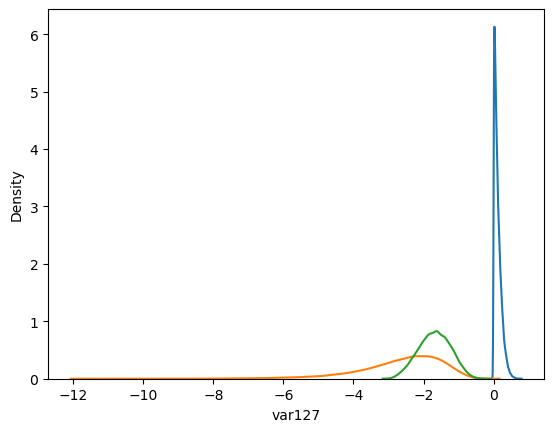

In [73]:
sns.kdeplot(data=src_train, x='var127', color=color_pal[0]) #azul
sns.kdeplot(data=src_train, x='var127_log', color=color_pal[1]) #naranja
sns.kdeplot(data=src_train, x='var127_normalized', color=color_pal[2]) #verde
plt.show()


In [75]:
vun_train = src_train[["ID", "var15", "num_var22_hace3",
 "num_var45_hace3", "num_var22_ult3", "num_var22_hace2", "num_med_var45_ult3",
 "num_var45_ult3", "ind_var30_0", "var38","var3", "num_med_var22_ult3", "saldo_medio_var12_ult3",
 "saldo_medio_var12_ult1", "saldo_var5", "saldo_var24", "saldo_var13", "saldo_var12",
 "num_var24_0", "ind_var20_0", "num_var13", "var36", "TARGET", "var127_log","var127_normalized"]]

# Bloque 4

In [77]:
#Separación dataframe
train_df, val_df = train_test_split(vun_train, test_size=0.3, random_state=42)

In [82]:
X = vun_train[['var15', 'num_var22_hace3', 'var127_log', 'var127_normalized']]
y = vun_train['TARGET']
X = sm.add_constant(X)
#ajuste
modelo = sm.Logit(y, X).fit()

print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.162591
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                38010
Model:                          Logit   Df Residuals:                    38005
Method:                           MLE   Df Model:                            4
Date:                Fri, 08 Aug 2025   Pseudo R-squ.:                 0.02781
Time:                        12:18:23   Log-Likelihood:                -6180.1
converged:                       True   LL-Null:                       -6356.8
Covariance Type:            nonrobust   LLR p-value:                 3.027e-75
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -4.4748      0.183    -24.465      0.000      -4.833      -4.116
var15   

In [85]:
X_null = sm.add_constant(pd.DataFrame({'intercept': [1]*len(y)}))
modelo_nulo = sm.Logit(y, X_null).fit()

Optimization terminated successfully.
         Current function value: 0.167241
         Iterations 7


In [86]:
print(modelo_nulo.summary())


                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:                38010
Model:                          Logit   Df Residuals:                    38009
Method:                           MLE   Df Model:                            0
Date:                Fri, 08 Aug 2025   Pseudo R-squ.:               1.560e-11
Time:                        12:20:59   Log-Likelihood:                -6356.8
converged:                       True   LL-Null:                       -6356.8
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -3.1838      0.026   -121.314      0.000      -3.235      -3.132
